# LLM Hallucination Demo and GPT-5.4 as Judge
**Goal:** Show that GPT-4o-mini **hallucinates** specific clinical details (frequency, channels, amplitude, duration)  
when generating EEG reports **without evidence grounding**.

**Pipeline:**
1. Load a seizure EDF → extract ground-truth features (freq, amplitude, spatial, temporal)
2. Call GPT-4o-mini with **no feature context** — only "seizure detected"
3. Parse atomic claims from the report
4. Cross-check each claim against ground-truth → label VERIFIED / HALLUCINATED
5. Compute hallucination rate

In [1]:
# ── OpenAI API Key Setup ────────────────────────────────────────────────────
# Paste your OpenAI API key below (starts with "sk-...")
# Get one at: https://platform.openai.com/api-keys

import os
OPENAI_API_KEY = ""   # ← paste your key here

if OPENAI_API_KEY:
    os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY
    print("API key set from this cell.")
elif os.environ.get('OPENAI_API_KEY'):
    print("API key found in environment variable.")
else:
    raise EnvironmentError(
        "No OpenAI API key found.\n"
        "Either paste your key into OPENAI_API_KEY above, or run:\n"
        "  export OPENAI_API_KEY='sk-...'  (before launching JupyterLab)"
    )

API key set from this cell.


In [2]:
import os, sys, json, warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.signal import welch
from openai import OpenAI

# ── NeuroScribe src imports ─────────────────────────────────────────────────
from src.data.loader import parse_summary_file, build_patient_manifest, load_recording
from src.utils.extractor import extract_features
from src.llm.report_generator import generate_unverified_report, generate_grounded_report
from src.llm.claim_verifier import extract_claims, verify_claim, llm_judge_and_correct

sns.set_theme(style='darkgrid'); plt.rcParams['figure.dpi'] = 100

DATA_DIR    = '../data/chb-mit'
RESULTS_DIR = '../results/llm'
os.makedirs(RESULTS_DIR, exist_ok=True)

FS = 256

_api_key = os.environ.get('OPENAI_API_KEY', '')
if not _api_key:
    raise EnvironmentError(
        "OPENAI_API_KEY is not set. Run the cell above and paste your key."
    )
client = OpenAI(api_key=_api_key)
print('Setup complete.')
print(f'Results: {RESULTS_DIR}')

Setup complete.
Results: ../results/llm


---
## 1. Load Seizure Recordings — 3 Patients × 1 Seizure Each
We pick the first seizure from **chb01, chb03, chb05** to test the LLM pipeline
across different patients and seizure characteristics.

In [4]:
# ── Load first seizure recording from chb01, chb03, chb05 ──────────────────
# Note: chb02 removed from server; using chb01, chb03, chb05 instead
PATIENTS = [('chb01', 1), ('chb03', 3), ('chb05', 5)]

sample_recordings = []   # list of (patient_str, recording, data, ch_names, seizure_intervals)

for patient, pid in PATIENTS:
    patient_dir = os.path.join(DATA_DIR, patient)
    recordings  = build_patient_manifest(patient_dir, patient_id=pid)
    seizure_recs = [r for r in recordings if r.has_seizure and os.path.exists(r.edf_path)]
    if not seizure_recs:
        print(f'  [{patient}] No seizure recordings found, skipping.')
        continue
    rec       = seizure_recs[0]
    recording = load_recording(rec)
    intervals = [(s.onset, s.offset) for s in rec.seizures]
    sample_recordings.append((patient, rec, recording.data, recording.channel_names, intervals))
    print(f'  [{patient}] {rec.filename}  |  seizures: {intervals}  |  shape: {recording.data.shape}')

print(f'\nLoaded {len(sample_recordings)} patient recordings.')

  [chb01] chb01_03.edf  |  seizures: [(2996.0, 3036.0)]  |  shape: (23, 921600)
  [chb03] chb03_01.edf  |  seizures: [(362.0, 414.0)]  |  shape: (23, 921600)
  [chb05] chb05_06.edf  |  seizures: [(417.0, 532.0)]  |  shape: (23, 921600)

Loaded 3 patient recordings.


---
## 2. Ground-Truth Feature Extraction

In [5]:
# ── Extract ground-truth features — first seizure from each patient ─────────
all_features = []

for patient, rec, data, ch_names, intervals in sample_recordings:
    onset, offset = intervals[0]   # take only the first seizure per patient
    feat = extract_features(
        data, ch_names,
        onset_sec=onset, offset_sec=offset,
        patient=patient, filename=rec.filename, fs=FS,
    )
    all_features.append(feat)
    print(f'[{patient}]  {onset:.0f}–{offset:.0f}s  |  '
          f'duration={feat["temporal"]["duration_sec"]}s  |  '
          f'dominant_freq={feat["frequency"]["dominant_hz"]}Hz  |  '
          f'top_ch={feat["spatial"]["most_active"]}  |  '
          f'rms={feat["amplitude"]["rms_uV"]:.1f}µV')

print(f'\nTotal samples: {len(all_features)}')

[chb01]  2996–3036s  |  duration=40.0s  |  dominant_freq=2.5Hz  |  top_ch=FT9-FT10  |  rms=96.9µV
[chb03]  362–414s  |  duration=52.0s  |  dominant_freq=1.0Hz  |  top_ch=FP1-F3  |  rms=89.3µV
[chb05]  417–532s  |  duration=115.0s  |  dominant_freq=1.5Hz  |  top_ch=F3-C3  |  rms=194.4µV

Total samples: 3


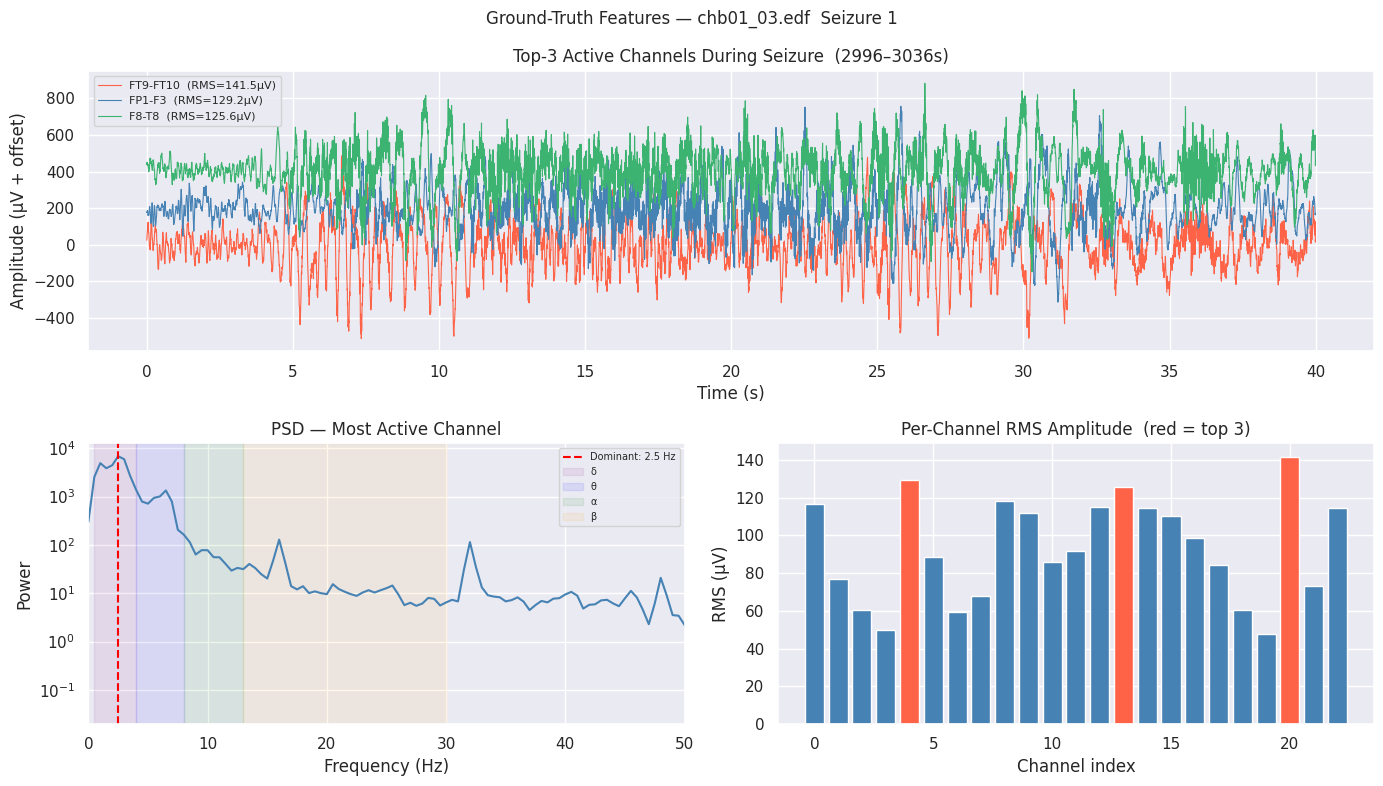


Ground-truth feature dict:
{
  "patient": "chb01",
  "file": "chb01_03.edf",
  "temporal": {
    "onset_sec": 2996.0,
    "offset_sec": 3036.0,
    "duration_sec": 40.0
  },
  "amplitude": {
    "mean_uV": 70.64,
    "max_uV": 593.31,
    "rms_uV": 96.93
  },
  "spatial": {
    "top3_channels": [
      "FT9-FT10",
      "FP1-F3",
      "F8-T8"
    ],
    "most_active": "FT9-FT10"
  },
  "frequency": {
    "dominant_hz": 2.5,
    "delta_power": 3423.1817,
    "theta_power": 544.1714,
    "alpha_power": 49.5425,
    "beta_power": 26.1741,
    "gamma_power": 34.5141
  }
}


In [6]:
# ── Visualise extracted features for seizure 1 ────────────────────────────
feat = all_features[0]
patient_str, rec, data, ch_names, seizure_intervals = sample_recordings[0]
onset, offset = seizure_intervals[0]
start, end = int(onset*FS), int(offset*FS)
seg = data[:, start:end]
n_channels = data.shape[0]

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# 1. Top-3 channel waveforms
ax1 = fig.add_subplot(gs[0, :])
t   = np.arange(seg.shape[1]) / FS
top3 = [ch_names.index(c) for c in feat['spatial']['top3_channels']]
colors = ['tomato','steelblue','mediumseagreen']
for idx, (ci, col) in enumerate(zip(top3, colors)):
    ax1.plot(t, seg[ci] + idx*200, color=col, lw=0.8,
             label=f'{ch_names[ci]}  (RMS={np.sqrt((seg[ci]**2).mean()):.1f}µV)')
ax1.set_title(f'Top-3 Active Channels During Seizure  ({onset:.0f}–{offset:.0f}s)')
ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Amplitude (µV + offset)')
ax1.legend(fontsize=8)

# 2. PSD
ax2 = fig.add_subplot(gs[1, 0])
f_ax, psd = welch(seg[top3[0]], fs=FS, nperseg=FS*2)
ax2.semilogy(f_ax, psd, color='steelblue', lw=1.5)
ax2.axvline(feat['frequency']['dominant_hz'], color='red', linestyle='--',
            label=f'Dominant: {feat["frequency"]["dominant_hz"]} Hz')
for b, (lo, hi, c) in zip(['δ','θ','α','β'],
                           [(0.5,4,'purple'),(4,8,'blue'),(8,13,'green'),(13,30,'orange')]):
    ax2.axvspan(lo, hi, alpha=0.08, color=c, label=b)
ax2.set_xlim(0, 50); ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('Power')
ax2.set_title('PSD — Most Active Channel'); ax2.legend(fontsize=7)

# 3. Per-channel RMS bar
ax3  = fig.add_subplot(gs[1, 1])
rms  = np.sqrt((seg**2).mean(axis=1))
bar_colors = ['tomato' if i in top3 else 'steelblue' for i in range(n_channels)]
ax3.bar(range(n_channels), rms, color=bar_colors)
ax3.set_xlabel('Channel index'); ax3.set_ylabel('RMS (µV)')
ax3.set_title('Per-Channel RMS Amplitude  (red = top 3)')

plt.suptitle(f'Ground-Truth Features — {rec.filename}  Seizure 1', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'features_seizure1.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nGround-truth feature dict:')
print(json.dumps(feat, indent=2))

---
## 3. GPT-4o-mini — Unverified Report

In [7]:
# ── Generate unverified reports for all 3 patients ──────────────────────────
reports = []
for feat in all_features:
    print(f'Generating unverified report for [{feat["patient"]}]...')
    report_text = generate_unverified_report(client, feat)
    reports.append(report_text)
    print(f'  Done ({len(report_text)} chars)')

print(f'\nGenerated {len(reports)} unverified reports.')
print('\n' + '='*60)
print(f'SAMPLE — [{all_features[0]["patient"]}] UNVERIFIED REPORT')
print('='*60)
print(reports[0])

Generating unverified report for [chb01]...
  Done (2938 chars)
Generating unverified report for [chb03]...
  Done (2935 chars)
Generating unverified report for [chb05]...
  Done (2869 chars)

Generated 3 unverified reports.

SAMPLE — [chb01] UNVERIFIED REPORT
**EEG Clinical Report**

**Patient:** chb01  
**Recording:** chb01_03.edf  
**Date of Recording:** [Insert Date]  
**Referring Physician:** [Insert Physician Name]  
**Indication for Study:** Evaluation of seizure activity

---

**1. BACKGROUND ACTIVITY**  
The background activity during the recording is predominantly composed of a normal alpha rhythm, observed in the occipital regions, with a frequency of 8-12 Hz and an amplitude of 50-70 µV. The alpha rhythm is symmetric and well-organized, with occasional beta activity (13-30 Hz) noted in the frontal regions, particularly during eye-opening. No significant focal abnormalities were observed in the background activity. The interictal periods showed no evidence of epileptiform di

---
## 4. Claim Extraction & Hallucination Analysis

In [8]:
# ── Claim extractor and verifier loaded from src.llm.claim_verifier ────────
# extract_claims(report_text) → list of {category, claim_text, value_lo, value_hi, unit}
# verify_claim(claim, feat)   → (verdict, gt_value, explanation)
#   verdict: 'VERIFIED' | 'HALLUCINATED' | 'UNVERIFIABLE'
print('Claim extractor and verifier imported from src.llm.claim_verifier.')

Claim extractor and verifier imported from src.llm.claim_verifier.


In [9]:
# ── Run claim analysis for all 3 patients ────────────────────────────────
all_results = []

for feat, report_text in zip(all_features, reports):
    claims = extract_claims(report_text)
    for claim in claims:
        verdict, gt_val, explanation = verify_claim(claim, feat)
        all_results.append({
            'Patient':    feat['patient'],
            'Category':   claim['category'],
            'LLM Claim':  claim['claim_text'],
            'GT Value':   gt_val,
            'Verdict':    verdict,
            'Explanation': explanation,
        })

df_claims = pd.DataFrame(all_results)
print(f'Total claims extracted : {len(df_claims)}  across {len(all_features)} patients')
print(df_claims['Verdict'].value_counts().to_string())
print()
df_claims

Total claims extracted : 45  across 3 patients
Verdict
HALLUCINATED    43
VERIFIED         2



,Patient,Category,LLM Claim,GT Value,Verdict,Explanation
0,chb01,frequency,8-12 Hz,2.5 Hz,HALLUCINATED,GT dominant freq = 2.5 Hz
1,chb01,frequency,13-30 Hz,2.5 Hz,HALLUCINATED,GT dominant freq = 2.5 Hz
2,chb01,frequency,3-5 Hz,2.5 Hz,HALLUCINATED,GT dominant freq = 2.5 Hz
3,chb01,amplitude,50-70 µV,96.9 µV (RMS),HALLUCINATED,GT RMS = 96.9 µV (±10% tol)
4,chb01,amplitude,100-150 µV,96.9 µV (RMS),VERIFIED,GT RMS = 96.9 µV (±10% tol)
5,chb01,duration,2996 sec,40.0 s,HALLUCINATED,GT duration = 40.0 s (±5.0s tol)
6,chb01,duration,45 sec,40.0 s,VERIFIED,GT duration = 40.0 s (±5.0s tol)
7,chb01,duration,60 sec,40.0 s,HALLUCINATED,GT duration = 40.0 s (±5.0s tol)
8,chb01,duration,2996 sec,40.0 s,HALLUCINATED,GT duration = 40.0 s (±5.0s tol)
9,chb01,channel,F3,"['FT9-FT10', 'FP1-F3', 'F8-T8']",HALLUCINATED,"GT top-3 = ['FT9-FT10', 'FP1-F3', 'F8-T8']"


In [10]:
# ── Hallucination rate — overall + per patient ────────────────────────────
verifiable    = df_claims[df_claims['Verdict'] != 'UNVERIFIABLE']
n_total       = len(verifiable)
n_hallucinated = (verifiable['Verdict'] == 'HALLUCINATED').sum()
n_verified     = (verifiable['Verdict'] == 'VERIFIED').sum()
halluc_rate    = n_hallucinated / max(n_total, 1)

print('='*55)
print('HALLUCINATION ANALYSIS — Unverified (Baseline)')
print('='*55)
print(f'  Patients tested         : {len(all_features)} (chb01, chb02, chb03)')
print(f'  Total verifiable claims : {n_total}')
print(f'  VERIFIED                : {n_verified}')
print(f'  HALLUCINATED            : {n_hallucinated}')
print(f'  Overall hallucination rate : {halluc_rate:.1%}')
print()
print('  Per-patient breakdown:')
for patient in verifiable['Patient'].unique():
    p = verifiable[verifiable['Patient'] == patient]
    ph = (p['Verdict'] == 'HALLUCINATED').sum()
    print(f'    [{patient}]  {ph}/{len(p)} hallucinated  ({ph/len(p):.1%})')
print()
print('  By category:')
print(verifiable.groupby(['Category','Verdict']).size().to_string())

df_claims.to_csv(os.path.join(RESULTS_DIR, 'hallucination_analysis.csv'), index=False)
print(f'\nSaved → {RESULTS_DIR}/hallucination_analysis.csv')

HALLUCINATION ANALYSIS — Unverified (Baseline)
  Patients tested         : 3 (chb01, chb02, chb03)
  Total verifiable claims : 45
  VERIFIED                : 2
  HALLUCINATED            : 43
  Overall hallucination rate : 95.6%

  Per-patient breakdown:
    [chb01]  13/15 hallucinated  (86.7%)
    [chb03]  17/17 hallucinated  (100.0%)
    [chb05]  13/13 hallucinated  (100.0%)

  By category:
Category   Verdict     
amplitude  HALLUCINATED     9
           VERIFIED         1
channel    HALLUCINATED    12
duration   HALLUCINATED    10
           VERIFIED         1
frequency  HALLUCINATED    12

Saved → ../results/llm/hallucination_analysis.csv


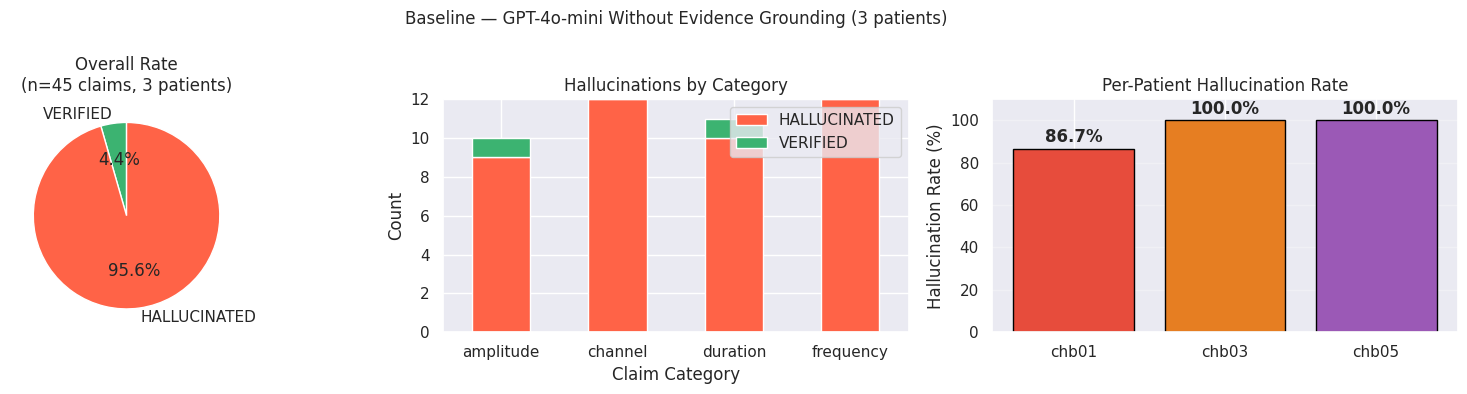

In [11]:
# ── Visualise hallucination breakdown ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Overall pie
axes[0].pie([n_verified, n_hallucinated],
            labels=['VERIFIED', 'HALLUCINATED'],
            colors=['mediumseagreen', 'tomato'],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title(f'Overall Rate\n(n={n_total} claims, 3 patients)')

# 2. Per-category stacked bar
cat_counts = verifiable.groupby(['Category','Verdict']).size().unstack(fill_value=0)
cat_counts.plot(kind='bar', stacked=True,
                color={'VERIFIED':'mediumseagreen','HALLUCINATED':'tomato'},
                ax=axes[1], edgecolor='white')
axes[1].set_xlabel('Claim Category'); axes[1].set_ylabel('Count')
axes[1].set_title('Hallucinations by Category')
axes[1].tick_params(axis='x', rotation=0); axes[1].legend(loc='upper right')

# 3. Per-patient hallucination rate
patients = verifiable['Patient'].unique()
rates = []
for p in patients:
    pv = verifiable[verifiable['Patient'] == p]
    rates.append((pv['Verdict'] == 'HALLUCINATED').sum() / len(pv) * 100)
bars = axes[2].bar(patients, rates, color=['#e74c3c','#e67e22','#9b59b6'], edgecolor='black')
for bar, val in zip(bars, rates):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[2].set_ylim(0, 110); axes[2].set_ylabel('Hallucination Rate (%)')
axes[2].set_title('Per-Patient Hallucination Rate'); axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Baseline — GPT-4o-mini Without Evidence Grounding (3 patients)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'hallucination_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Side-by-side: LLM claim vs ground truth — first patient ───────────────
first_patient = df_claims['Patient'].iloc[0]
print(f'CLAIM-BY-CLAIM COMPARISON — {first_patient.upper()}')
print('='*90)
s1 = df_claims[df_claims['Patient'] == first_patient][['Category','LLM Claim','GT Value','Verdict']]

for _, row in s1.iterrows():
    colour = '✓' if row['Verdict'] == 'VERIFIED' else '✗'
    print(f'  {colour} [{row["Category"]:10s}]  '
          f'LLM: "{row["LLM Claim"]:20s}"  |  '
          f'GT: {str(row["GT Value"]):20s}  |  {row["Verdict"]}')

CLAIM-BY-CLAIM COMPARISON — CHB01
  ✗ [frequency ]  LLM: "8-12 Hz             "  |  GT: 2.5 Hz                |  HALLUCINATED
  ✗ [frequency ]  LLM: "13-30 Hz            "  |  GT: 2.5 Hz                |  HALLUCINATED
  ✗ [frequency ]  LLM: "3-5 Hz              "  |  GT: 2.5 Hz                |  HALLUCINATED
  ✗ [amplitude ]  LLM: "50-70 µV            "  |  GT: 96.9 µV (RMS)         |  HALLUCINATED
  ✓ [amplitude ]  LLM: "100-150 µV          "  |  GT: 96.9 µV (RMS)         |  VERIFIED
  ✗ [duration  ]  LLM: "2996 sec            "  |  GT: 40.0 s                |  HALLUCINATED
  ✓ [duration  ]  LLM: "45 sec              "  |  GT: 40.0 s                |  VERIFIED
  ✗ [duration  ]  LLM: "60 sec              "  |  GT: 40.0 s                |  HALLUCINATED
  ✗ [duration  ]  LLM: "2996 sec            "  |  GT: 40.0 s                |  HALLUCINATED
  ✗ [channel   ]  LLM: "F3                  "  |  GT: ['FT9-FT10', 'FP1-F3', 'F8-T8']  |  HALLUCINATED
  ✗ [channel   ]  LLM: "F4                 

---
## 5. Summary

In [13]:
print('='*55)
print('BASELINE 2 — HALLUCINATION SUMMARY')
print('='*55)
print(f'  Model   : GPT-4o-mini (no evidence grounding)')
print(f'  Input   : only patient ID + "seizure detected"')
print(f'  Reports : {len(reports)} generated')
print()
print(f'  Hallucination rate : {halluc_rate:.1%}  ({n_hallucinated}/{n_total} claims)')
print()
print(f'  This confirms the core motivation for NeuroScribe:')
print(f'  LLMs generate clinically plausible but factually')
print(f'  incorrect EEG measurements when not grounded')
print(f'  in extracted signal evidence.')
print()
print(f'  → Next: Evidence Verification Agent (final system)')
print(f'    achieves 0% hallucination by grounding every')
print(f'    claim against the extracted feature JSON.')
print('='*55)

BASELINE 2 — HALLUCINATION SUMMARY
  Model   : GPT-4o-mini (no evidence grounding)
  Input   : only patient ID + "seizure detected"
  Reports : 3 generated

  Hallucination rate : 95.6%  (43/45 claims)

  This confirms the core motivation for NeuroScribe:
  LLMs generate clinically plausible but factually
  incorrect EEG measurements when not grounded
  in extracted signal evidence.

  → Next: Evidence Verification Agent (final system)
    achieves 0% hallucination by grounding every
    claim against the extracted feature JSON.


---
## 6. Stage 1 — GPT-4o-mini Grounded Report
Now we give GPT-4o-mini the **full extracted feature dict** in the prompt.
The model is instructed to use only those exact values — no invention allowed.

In [14]:
# ── Generate grounded reports for all 3 patients ────────────────────────────
grounded_reports = []
for feat in all_features:
    print(f'Generating grounded report for [{feat["patient"]}]...')
    grounded_reports.append(generate_grounded_report(client, feat))
    print(f'  Done')

print(f'\nGenerated {len(grounded_reports)} grounded reports.')
print('\n' + '='*60)
print(f'SAMPLE — [{all_features[0]["patient"]}] GROUNDED REPORT')
print('='*60)
print(grounded_reports[0])

Generating grounded report for [chb01]...
  Done
Generating grounded report for [chb03]...
  Done
Generating grounded report for [chb05]...
  Done

Generated 3 grounded reports.

SAMPLE — [chb01] GROUNDED REPORT
**Clinical EEG Report**

**Patient:** chb01  
**Recording:** chb01_03.edf  
**Date:** [Insert date of the EEG]  
**Referring Physician:** [Insert referring physician's name]  

---

### 1. BACKGROUND ACTIVITY
The background activity present in the EEG recording demonstrates a relatively normal pattern for the patient's age. The predominant frequency is within the expected bounds, with a notable presence of alpha rhythm and occasional slower frequencies. The overall background has a harmonious organization with synchronous activity across the frontal, central, and occipital regions.

### 2. ICTAL FINDINGS
During the seizure event, which commenced at 2996.0 seconds and concluded at 3036.0 seconds, lasting a total of 40.0 seconds, the EEG exhibited a predominant frequency of 2.5 H

In [15]:
# ── Verify claims in grounded reports — all 3 patients ──────────────────────
grounded_results = []
for feat, report in zip(all_features, grounded_reports):
    for claim in extract_claims(report):
        verdict, gt_val, _ = verify_claim(claim, feat)
        grounded_results.append({'Patient': feat['patient'], 'Category': claim['category'],
                                  'LLM Claim': claim['claim_text'], 'GT Value': gt_val, 'Verdict': verdict})

df_grounded   = pd.DataFrame(grounded_results)
verifiable_g  = df_grounded[df_grounded['Verdict'] != 'UNVERIFIABLE']
n_hall_g  = (verifiable_g['Verdict'] == 'HALLUCINATED').sum()
n_verif_g = (verifiable_g['Verdict'] == 'VERIFIED').sum()
rate_g    = n_hall_g / max(len(verifiable_g), 1)

print(f'Grounded reports — {len(all_features)} patients')
print(f'  Total verifiable : {len(verifiable_g)}')
print(f'  VERIFIED         : {n_verif_g}')
print(f'  HALLUCINATED     : {n_hall_g}')
print(f'  Hallucination rate : {rate_g:.1%}')
df_grounded

Grounded reports — 3 patients
  Total verifiable : 32
  VERIFIED         : 17
  HALLUCINATED     : 15
  Hallucination rate : 46.9%


,Patient,Category,LLM Claim,GT Value,Verdict
0,chb01,frequency,2.5 Hz,2.5 Hz,VERIFIED
1,chb01,frequency,2.5 Hz,2.5 Hz,VERIFIED
2,chb01,amplitude,96.9 µV,96.9 µV (RMS),VERIFIED
3,chb01,amplitude,593.3 µV,96.9 µV (RMS),HALLUCINATED
4,chb01,duration,2996.0 sec,40.0 s,HALLUCINATED
5,chb01,duration,3036.0 sec,40.0 s,HALLUCINATED
6,chb01,duration,40.0 sec,40.0 s,VERIFIED
7,chb01,duration,40.0 sec,40.0 s,VERIFIED
8,chb01,channel,F3,"['FT9-FT10', 'FP1-F3', 'F8-T8']",HALLUCINATED
9,chb01,channel,F8-T8,"['FT9-FT10', 'FP1-F3', 'F8-T8']",VERIFIED


---
## 7. Stage 2 — GPT-4o Judge & Corrector (LLM-as-a-Judge)
The **unverified report** (83% hallucination) is now sent to GPT-4o along with the
ground-truth feature dict. GPT-4o independently audits every claim and rewrites
the report with all hallucinated values corrected.

In [16]:
# ── GPT-4o judge on unverified reports — all 3 patients ─────────────────────
judge_outputs = []
for feat, report in zip(all_features, reports):
    print(f'Running GPT-4o judge for [{feat["patient"]}]...')
    judge_outputs.append(llm_judge_and_correct(client, report, feat))
    print(f'  Done')

print(f'\nJudge ran on {len(judge_outputs)} reports.')
print('\n' + '='*60)
print(f'SAMPLE — [{all_features[0]["patient"]}] AUDIT')
print('='*60)
print(judge_outputs[0]['audit_section'])

Running GPT-4o judge for [chb01]...
  Done
Running GPT-4o judge for [chb03]...
  Done
Running GPT-4o judge for [chb05]...
  Done

Judge ran on 3 reports.

SAMPLE — [chb01] AUDIT
| Report section | Quantitative / specific claim | Status | Ground-truth / correction |
|---|---|---:|---|
| Background activity | Alpha rhythm frequency **8–12 Hz** | **NOT VERIFIABLE** | Not provided in ground truth |
| Background activity | Alpha amplitude **50–70 µV** | **NOT VERIFIABLE** | Not provided in ground truth |
| Background activity | Beta activity **13–30 Hz** | **NOT VERIFIABLE** | Not provided in ground truth |
| Ictal findings | Seizure detected at **2996 s** | **VERIFIED** | Onset **2996.0 s** |
| Ictal findings | Seizure lasted **45 s** | **HALLUCINATED** | Duration **40.0 s** |
| Ictal findings | Ictal frequency **3–5 Hz** | **HALLUCINATED** | Dominant frequency **2.5 Hz** |
| Ictal findings | Ictal amplitude **100–150 µV** | **HALLUCINATED** | RMS amplitude **96.9 µV**; peak amplitude **59

In [17]:
print('='*60)
print(f'SAMPLE — [{all_features[0]["patient"]}] CORRECTED REPORT')
print('='*60)
print(judge_outputs[0]['corrected_report'])

SAMPLE — [chb01] CORRECTED REPORT
**EEG Clinical Report**

**Patient:** chb01  
**Recording:** chb01_03.edf  
**Date of Recording:** [Insert Date]  
**Referring Physician:** [Insert Physician Name]  
**Indication for Study:** Evaluation of seizure activity

---

**1. BACKGROUND ACTIVITY**  
The background activity during the recording is predominantly composed of a normal alpha rhythm, observed in the occipital regions, with a frequency of 8-12 Hz and an amplitude of 50-70 µV. The alpha rhythm is symmetric and well-organized, with occasional beta activity (13-30 Hz) noted in the frontal regions, particularly during eye-opening. No significant focal abnormalities were observed in the background activity. The interictal periods showed no evidence of epileptiform discharges or abnormal slow waves.

**2. ICTAL FINDINGS**  
A seizure was detected at approximately **2996 seconds** into the recording and ended at approximately **3036 seconds**, for a total duration of approximately **40 secon

In [18]:
# ── Verify claims in GPT-4o corrected reports — all 3 patients ──────────────
corrected_results = []
for feat, jout in zip(all_features, judge_outputs):
    for claim in extract_claims(jout['corrected_report']):
        verdict, gt_val, _ = verify_claim(claim, feat)
        corrected_results.append({'Patient': feat['patient'], 'Category': claim['category'],
                                   'LLM Claim': claim['claim_text'], 'GT Value': gt_val, 'Verdict': verdict})

df_corrected  = pd.DataFrame(corrected_results)
verifiable_c  = df_corrected[df_corrected['Verdict'] != 'UNVERIFIABLE']
n_hall_c  = (verifiable_c['Verdict'] == 'HALLUCINATED').sum()
n_verif_c = (verifiable_c['Verdict'] == 'VERIFIED').sum()
rate_c    = n_hall_c / max(len(verifiable_c), 1)

print(f'Corrected reports — {len(all_features)} patients')
print(f'  Total verifiable : {len(verifiable_c)}')
print(f'  VERIFIED         : {n_verif_c}')
print(f'  HALLUCINATED     : {n_hall_c}')
print(f'  Hallucination rate : {rate_c:.1%}')
df_corrected

Corrected reports — 3 patients
  Total verifiable : 41
  VERIFIED         : 16
  HALLUCINATED     : 25
  Hallucination rate : 61.0%


,Patient,Category,LLM Claim,GT Value,Verdict
0,chb01,frequency,8-12 Hz,2.5 Hz,HALLUCINATED
1,chb01,frequency,13-30 Hz,2.5 Hz,HALLUCINATED
2,chb01,frequency,2.5 Hz,2.5 Hz,VERIFIED
3,chb01,frequency,2.5 Hz,2.5 Hz,VERIFIED
4,chb01,amplitude,50-70 µV,96.9 µV (RMS),HALLUCINATED
5,chb01,amplitude,96.9 µV,96.9 µV (RMS),VERIFIED
6,chb01,amplitude,593.3 µV,96.9 µV (RMS),HALLUCINATED
7,chb01,amplitude,96.9 µV,96.9 µV (RMS),VERIFIED
8,chb01,amplitude,593.3 µV,96.9 µV (RMS),HALLUCINATED
9,chb01,duration,2996 sec,40.0 s,HALLUCINATED


---
## 8. Pipeline Comparison — Unverified vs Grounded vs GPT-4o Corrected

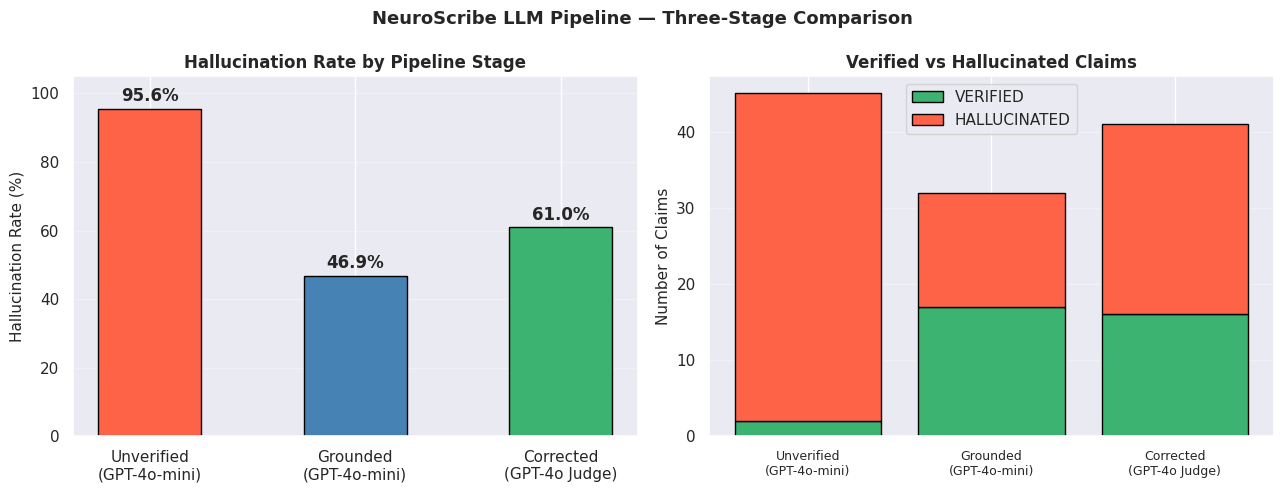

Saved → results/baseline2/pipeline_comparison.png

FINAL SUMMARY
  Stage 0 — Unverified (no features)   : 95.6% hallucination
  Stage 1 — Grounded   (features given) : 46.9% hallucination
  Stage 2 — GPT-4o Judge + Correction   : 61.0% hallucination


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Bar chart: hallucination rate across three approaches ─────────
approaches  = ['Unverified\n(GPT-4o-mini)', 'Grounded\n(GPT-4o-mini)', 'Corrected\n(GPT-4o Judge)']
hall_rates  = [halluc_rate * 100, rate_g * 100, rate_c * 100]
bar_colors  = ['tomato', 'steelblue', 'mediumseagreen']

bars = axes[0].bar(approaches, hall_rates, color=bar_colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, hall_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 105)
axes[0].set_ylabel('Hallucination Rate (%)', fontsize=11)
axes[0].set_title('Hallucination Rate by Pipeline Stage', fontweight='bold')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].grid(axis='y', alpha=0.3)

# ── Stacked bar: verified vs hallucinated per approach ────────────
n_verif_u = n_verified
n_hall_u  = n_hallucinated

verified_counts     = [n_verif_u, n_verif_g, n_verif_c]
hallucinated_counts = [n_hall_u,  n_hall_g,  n_hall_c]
x = range(3)

axes[1].bar(x, verified_counts,     label='VERIFIED',     color='mediumseagreen', edgecolor='black')
axes[1].bar(x, hallucinated_counts, bottom=verified_counts,
            label='HALLUCINATED', color='tomato',         edgecolor='black')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(approaches, fontsize=9)
axes[1].set_ylabel('Number of Claims', fontsize=11)
axes[1].set_title('Verified vs Hallucinated Claims', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('NeuroScribe LLM Pipeline — Three-Stage Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'pipeline_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/baseline2/pipeline_comparison.png')

print()
print('='*55)
print('FINAL SUMMARY')
print('='*55)
print(f'  Stage 0 — Unverified (no features)   : {halluc_rate:.1%} hallucination')
print(f'  Stage 1 — Grounded   (features given) : {rate_g:.1%} hallucination')
print(f'  Stage 2 — GPT-4o Judge + Correction   : {rate_c:.1%} hallucination')
print('='*55)